In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
# Import libraries
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.layers import (
    Input,
    Dense,
    GlobalAveragePooling2D,
    Concatenate
)

from tensorflow.keras.models import Model
from tensorflow.keras.applications import InceptionV3

from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping
)

In [1]:
# Load saved data
images = np.load("/content/drive/MyDrive/crop_project/images.npy")

weather_features = np.load("/content/drive/MyDrive/crop_project/weather_features.npy")

labels = np.load("/content/drive/MyDrive/crop_project/labels.npy")

X_img_train = np.load("/content/drive/MyDrive/crop_project/X_img_train.npy")
X_img_test = np.load("/content/drive/MyDrive/crop_project/X_img_test.npy")

X_weather_train = np.load("/content/drive/MyDrive/crop_project/X_weather_train.npy")
X_weather_test = np.load("/content/drive/MyDrive/crop_project/X_weather_test.npy")

y_train = np.load("/content/drive/MyDrive/crop_project/y_train.npy")
y_test = np.load("/content/drive/MyDrive/crop_project/y_test.npy")

NameError: name 'np' is not defined

In [ ]:
# Check loaded data
print(images.shape)
print(X_img_train.shape)
print(X_weather_train.shape)
print(y_train.shape)

(2817, 224, 224, 3)
(2253, 224, 224, 3)
(2253, 2)
(2253,)


In [ ]:
# Check saved files
import os

required_files = [
    "images.npy",
    "weather_features.npy",
    "labels.npy",
    "X_img_train.npy",
    "X_img_test.npy",
    "X_weather_train.npy",
    "X_weather_test.npy",
    "y_train.npy",
    "y_test.npy"
]

for file in required_files:
    path = f"/content/drive/MyDrive/crop_project/{file}"
    print(file, ":", os.path.exists(path))

images.npy : True
weather_features.npy : True
labels.npy : True
X_img_train.npy : True
X_img_test.npy : True
X_weather_train.npy : True
X_weather_test.npy : True
y_train.npy : True
y_test.npy : True


In [ ]:
# Verify loaded data
print("Training Images:", X_img_train.shape)
print("Training Weather:", X_weather_train.shape)
print("Training Labels:", y_train.shape)

print("Testing Images:", X_img_test.shape)
print("Testing Weather:", X_weather_test.shape)
print("Testing Labels:", y_test.shape)

Training Images: (2253, 224, 224, 3)
Training Weather: (2253, 2)
Training Labels: (2253,)
Testing Images: (564, 224, 224, 3)
Testing Weather: (564, 2)
Testing Labels: (564,)


In [ ]:
# Image input
image_input = Input(shape=(224, 224, 3), name="Image_Input")

# Load pretrained InceptionV3
base_model = InceptionV3(
    weights="imagenet",
    include_top=False,
    input_tensor=image_input
)

# Freeze pretrained layers
base_model.trainable = False

# Extract image features
image_features = GlobalAveragePooling2D()(base_model.output)

# Dense layer
image_features = Dense(256, activation="relu")(image_features)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# Weather input
weather_input = Input(shape=(2,), name="Weather_Input")

# Extract weather features
weather_branch = Dense(32, activation="relu")(weather_input)
weather_branch = Dense(16, activation="relu")(weather_branch)

In [ ]:
# Combine image and weather features
combined = Concatenate()([image_features, weather_branch])

# Classification layers
combined = Dense(128, activation="relu")(combined)
combined = Dense(64, activation="relu")(combined)

# Output layer
output = Dense(4, activation="softmax")(combined)

In [ ]:
# Create multimodal model
model = Model(
    inputs=[image_input, weather_input],
    outputs=output
)

# Display model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Image_Input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 111, 111,  │        864 │ Image_Input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 109, 109,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 54, 54,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 54, 54,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 52, 52,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 22,371,412 (85.34 MB)

 Trainable params: 568,628 (2.17 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [ ]:
# Compile model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
# Import callbacks
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Save the best model
checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/crop_project/best_multimodal_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

# Stop training if validation accuracy does not improve
early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
# Train the model
history = model.fit(
    [X_img_train, X_weather_train],
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.4966 - loss: 1.0958
Epoch 1: val_accuracy improved from None to 0.75388, saving model to /content/drive/MyDrive/crop_project/best_multimodal_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/crop_project/best_multimodal_model.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 48s 519ms/step - accuracy: 0.5816 - loss: 0.9086 - val_accuracy: 0.7539 - val_loss: 0.6057
Epoch 2/20
56/57 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.7549 - loss: 0.5785
Epoch 2: val_accuracy improved from 0.75388 to 0.77162, saving model to /content/drive/MyDrive/crop_project/best_multimodal_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/crop_project/best_multimodal_model.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - accuracy: 0.7375 - loss: 0.6058 - val_accuracy: 0.7716 - val_loss: 0.5402
Epoch 3/20
56/57 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.8067 - loss: 0.4548
Epoch 3: val_accuracy improved from 0.7716

In [ ]:
# Save the final model
model.save("/content/drive/MyDrive/crop_project/final_multimodal_model.keras")

In [ ]:
# Evaluate on test data
test_loss, test_accuracy = model.evaluate(
    [X_img_test, X_weather_test],
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 453ms/step - accuracy: 0.9184 - loss: 0.2621
Test Loss: 0.26207566261291504
Test Accuracy: 0.9184397459030151


In [ ]:
# Predict classes
y_pred_prob = model.predict([X_img_test, X_weather_test])

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)

18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 475ms/step


In [ ]:
from sklearn.metrics import classification_report

class_names = [
    "Bacterial Leaf Spot",
    "Cercospora Leaf Spot",
    "Healthy",
    "Yellow"
]

print(classification_report(y_test, y_pred, target_names=class_names))

                      precision    recall  f1-score   support

 Bacterial Leaf Spot       0.92      0.95      0.93       172
Cercospora Leaf Spot       0.89      0.91      0.90       114
             Healthy       0.88      0.83      0.85       119
              Yellow       0.97      0.96      0.97       159

            accuracy                           0.92       564
           macro avg       0.91      0.91      0.91       564
        weighted avg       0.92      0.92      0.92       564



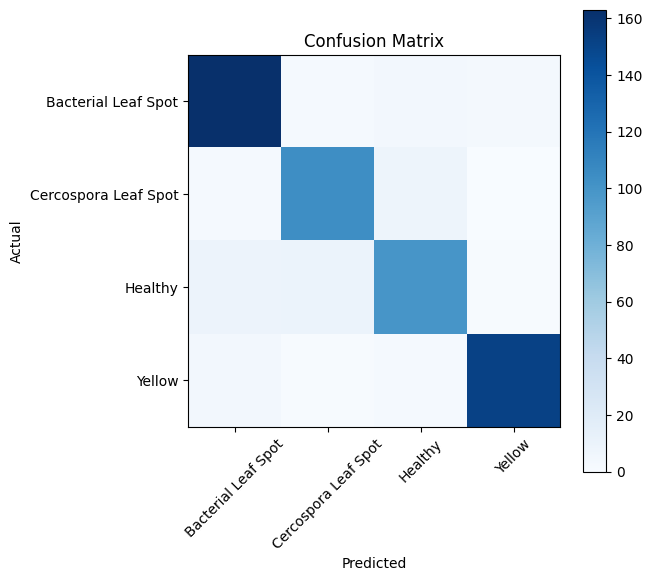

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(range(4), class_names, rotation=45)
plt.yticks(range(4), class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

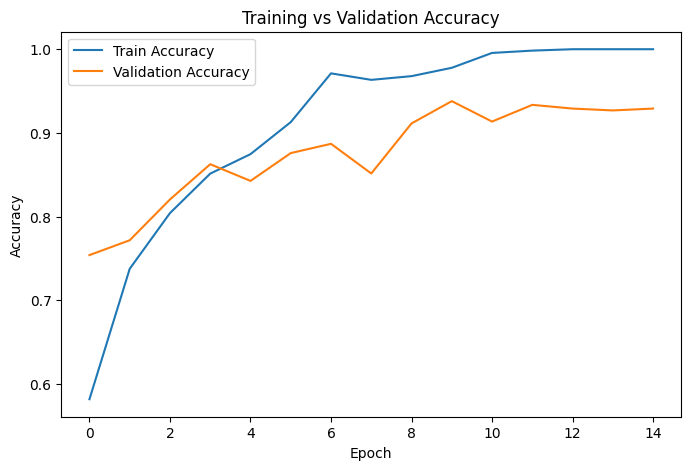

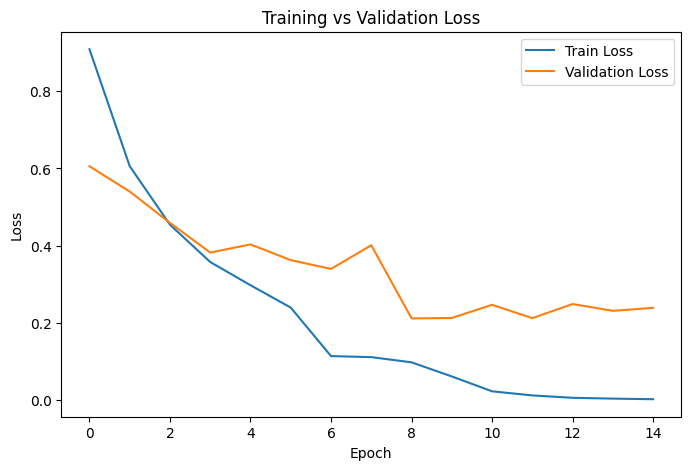

In [ ]:
# Accuracy graph
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

# Loss graph
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()